In [5]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter, medfilt

In [6]:
logs_dir = Path('/home/erie/Tonometry/logs')
# normal_limb_path = r'/home/erie/Tonometry/logs/3min_normal_limb.csv'
# pressure_limb_path = r'/home/erie/Tonometry/logs/weights_sequence_20250929_102708.csv'
normal_limb_path = r'/home/erie/Tonometry/logs/weights_sequence_20250929_172954.csv'
# normal_limb_path = r'/home/erie/Tonometry/logs/kaiwen_normal.csv' 
# pressure_limb_path_1 = r'/home/erie/Tonometry/logs/kaiwen_pressure_60mmHg.csv'
# pressure_limb_path_2 = r'/home/erie/Tonometry/logs/weights_sequence_20250929_104741.csv'
# pressure_limb_path_2 = r'/home/erie/Tonometry/logs/weights_sequence_20250929_170610.csv'
# pressure_limb_path_2 = r'/home/erie/Tonometry/logs/3min_60mmHg.csv'

In [7]:
def lvdt_csv_read(file_path):
    data = pd.read_csv(file_path, skiprows=1, header=None)
    time = data.iloc[:, 0].to_numpy()
    lvdt_voltage = data.iloc[:, 1].to_numpy()
    lvdt_disp = data.iloc[:, 2].to_numpy()
    motor_state = data.iloc[:, 3]

    t_max = time.max()

    mask = (time >= t_max - 26) & (time <= t_max)
    time = time[mask]
    time = time - time[0]  # Reset time to start from zero
    lvdt_disp = lvdt_disp[mask]
    # Reset displacement baseline after smoothing
    # lvdt_disp = savgol_filter(lvdt_disp, window_length=15, polyorder=3)
    lvdt_disp = medfilt(lvdt_disp, kernel_size=7)
    lvdt_disp = lvdt_disp - lvdt_disp[0]  # Reset displacement to start from zero

    return np.vstack((time, lvdt_disp)).T


In [8]:
nomarl_limb_data = lvdt_csv_read(normal_limb_path)
# pressure_limb_data_1 = lvdt_csv_read(pressure_limb_path_1)
# pressure_limb_data_2 = lvdt_csv_read(pressure_limb_path_2)

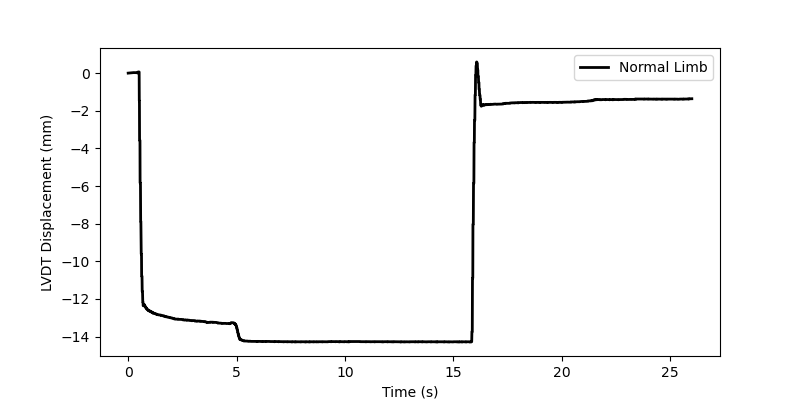

In [9]:
plt.figure(figsize=(8, 4))
lw = 2
plt.plot(nomarl_limb_data[:,0], nomarl_limb_data[:,1], color = 'black', linewidth = lw, label = 'Normal Limb')
# plt.plot(pressure_limb_data_1[:,0], pressure_limb_data_1[:,1], color = 'orange', linestyle = "--", linewidth = lw, label = 'Pressure 60mmHg')
# plt.plot(pressure_limb_data_2[:,0], pressure_limb_data_2[:,1], color = 'red', linestyle = "-.", linewidth = lw, label = 'Pressure 60mmHg')
# plt.xlim(0, max(np.max(pressure_limb_data_2[:,0]), np.max(nomarl_limb_data[:,0])))
# plt.xlim(4.5,10)
# plt.ylim(-12,-10)
plt.xlabel('Time (s)')
plt.ylabel('LVDT Displacement (mm)')
plt.legend()
# plt.savefig(f"Normal_vs_pressured_limb_long_indent.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()